In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error


HourlyEngryComps = pd.read_csv("AEP_hourly.csv", parse_dates=['Datetime'], index_col='Datetime')

print(HourlyEngryComps.head().to_string())
print("\n")
print(HourlyEngryComps.info())
print("\n")
print(HourlyEngryComps.shape)

print("Data Shape:", HourlyEngryComps.shape)
print("\nData Types:\n", HourlyEngryComps.dtypes)
print("\nMissing Values:\n", HourlyEngryComps.isnull().sum())
print("\nSummary Statistics Of Data:\n", HourlyEngryComps.describe(include='all'))

# Extract the main series
EngrSers = HourlyEngryComps['AEP_MW']
print("Data Head:\n", EngrSers.head().to_string())

                      AEP_MW
Datetime                    
2004-12-31 01:00:00  13478.0
2004-12-31 02:00:00  12865.0
2004-12-31 03:00:00  12577.0
2004-12-31 04:00:00  12517.0
2004-12-31 05:00:00  12670.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 121273 entries, 2004-12-31 01:00:00 to 2018-01-02 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   AEP_MW  121273 non-null  float64
dtypes: float64(1)
memory usage: 1.9 MB
None


(121273, 1)
Data Shape: (121273, 1)

Data Types:
 AEP_MW    float64
dtype: object

Missing Values:
 AEP_MW    0
dtype: int64

Summary Statistics Of Data:
               AEP_MW
count  121273.000000
mean    15499.513717
std      2591.399065
min      9581.000000
25%     13630.000000
50%     15310.000000
75%     17200.000000
max     25695.000000
Data Head:
 Datetime
2004-12-31 01:00:00    13478.0
2004-12-31 02:00:00    12865.0
2004-12-31 03:00:00    12577.0
2004-12-31 04:00:00    12517.0
2

In [4]:

def OrganisingDatasets(Horengys):
    if not isinstance(Horengys.index, pd.DatetimeIndex):
        Horengys.index = pd.to_datetime(Horengys.index)
    ts = Horengys['AEP_MW']
    EnergyRatemonts = ts.resample('ME').mean()  # 'ME' = month end
    return EnergyRatemonts

def DecmpSeasnlFunc(series, period=12, model_type='multiplicative'):
    DecaptedSet = seasonal_decompose(series, model=model_type, period=period)
    Vtsets = DecaptedSet.plot()
    Vtsets.set_size_inches(12, 8)
    plt.show()


In [5]:


def PltsShifitingAvgs(series):
    MontlyEngrs = series.to_frame(name='AEP_MW')
    MontlyEngrs['MA_6'] = MontlyEngrs['AEP_MW'].rolling(window=6, min_periods=1).mean()
    MontlyEngrs['MA_12'] = MontlyEngrs['AEP_MW'].rolling(window=12, min_periods=1).mean()

    plt.figure(figsize=(12, 6))
    plt.plot(MontlyEngrs['AEP_MW'], label='Actual')
    plt.plot(MontlyEngrs['MA_6'], label='6-Month MA', linestyle='--')
    plt.plot(MontlyEngrs['MA_12'], label='12-Month MA', color='red')
    plt.legend()
    plt.title('Moving Averages Smoothing')
    plt.show()
    return MontlyEngrs

def HalyEngrsDataResampling(MontlyEngrs):
    HalyEngrsData = MontlyEngrs['AEP_MW'].resample('QE').mean()  
    plt.figure(figsize=(12, 5))
    plt.plot(HalyEngrsData, label="HalyEngrsData Average AEP_MW")
    plt.legend()
    plt.title("HalyEngrsData Resampled AEP_MW")
    plt.show()
    return HalyEngrsData

In [6]:

def ForecastingFuncts(series, order=(2,1,1), test_size=12):
    TrainDatasets = series.iloc[:-test_size]
    TestDatasets = series.iloc[-test_size:]

    model = ARIMA(TrainDatasets, order=order)
    result = model.fit()

    forecast = result.forecast(steps=test_size)
    rmse = np.sqrt(mean_squared_error(TestDatasets, forecast))
    print(f"RMSE: {rmse:.4f}")

    plt.figure(figsize=(12,6))
    plt.plot(TrainDatasets.index, TrainDatasets, label='Training Data')
    plt.plot(TestDatasets.index, TestDatasets, label='Actual', color='blue')
    plt.plot(TestDatasets.index, forecast, label='Forecast', color='red', linestyle='--')
    plt.fill_between(TestDatasets.index, forecast*0.9, forecast*1.1, alpha=0.2) # ±10% range
    plt.title(f"ARIMA Forecast (RMSE={rmse:.2f})")
    plt.legend()
    plt.show()


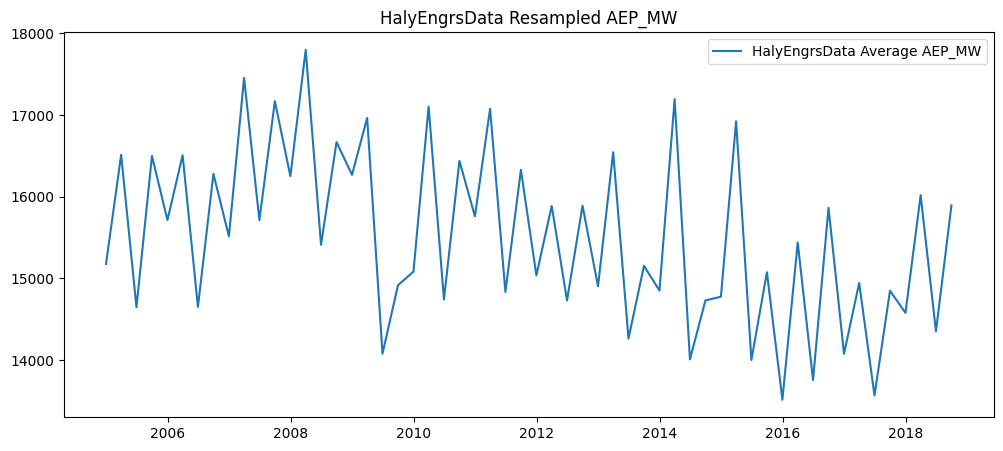

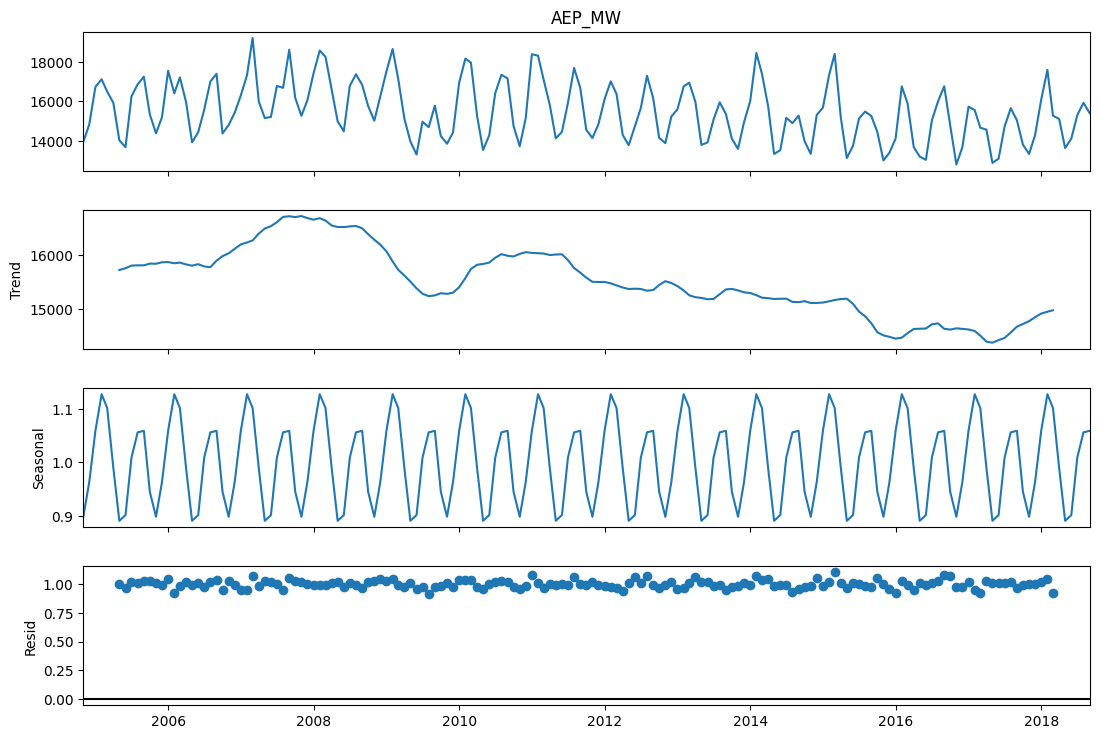

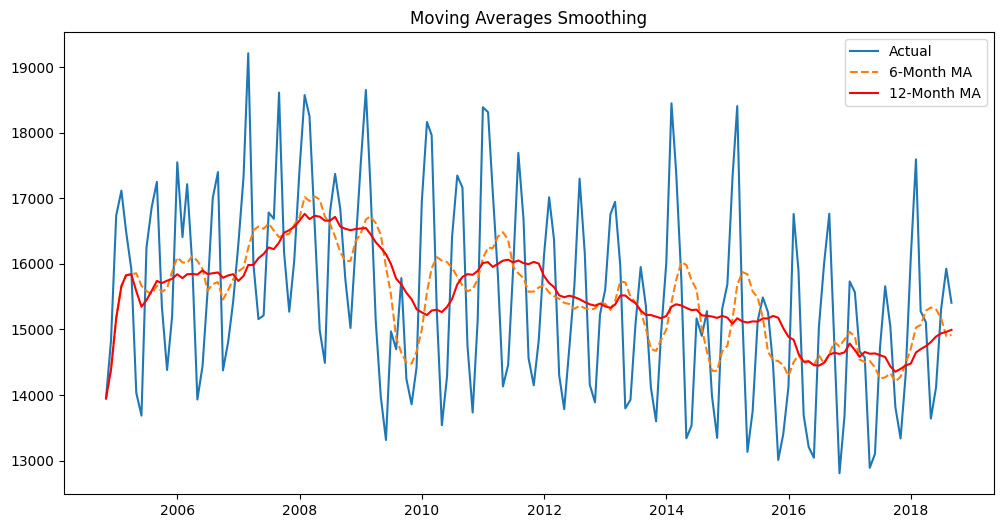

RMSE: 1181.1351


c:\Python Software\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


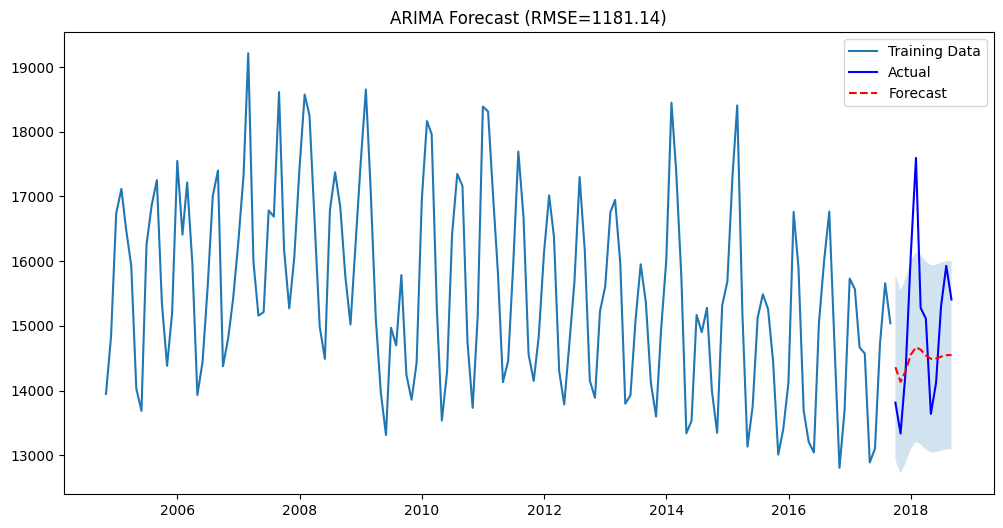

Completed Successfully
The First Few Rows of the Final DataFrame:
                  AEP_MW          MA_6         MA_12
Datetime                                            
2004-10-31  13947.537736  13947.537736  13947.537736
2004-11-30  14830.440278  14388.989007  14388.989007
2004-12-31  16737.720430  15171.899481  15171.899481
2005-01-31  17117.088710  15658.196788  15658.196788
2005-02-28  16496.644345  15825.886300  15825.886300
Index(['AEP_MW'], dtype='object')


In [7]:
DiminishedEneragdarat = OrganisingDatasets(HourlyEngryComps)       
HalyEngrsDataResampling(HourlyEngryComps)                 
DecmpSeasnlFunc(DiminishedEneragdarat, period=12)       
DiminishedEneragdarat_df = PltsShifitingAvgs(DiminishedEneragdarat)    
ForecastingFuncts(DiminishedEneragdarat_df['AEP_MW'], order=(2,1,1), test_size=12)  

print("Completed Successfully")
print("The First Few Rows of the Final DataFrame:")
print(DiminishedEneragdarat_df.head().to_string())
print(HourlyEngryComps.columns)
